In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [32]:
df = pd.read_csv('Advertising.csv')
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [33]:
df=df.drop(columns='Unnamed: 0' , axis=1)

In [34]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [35]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

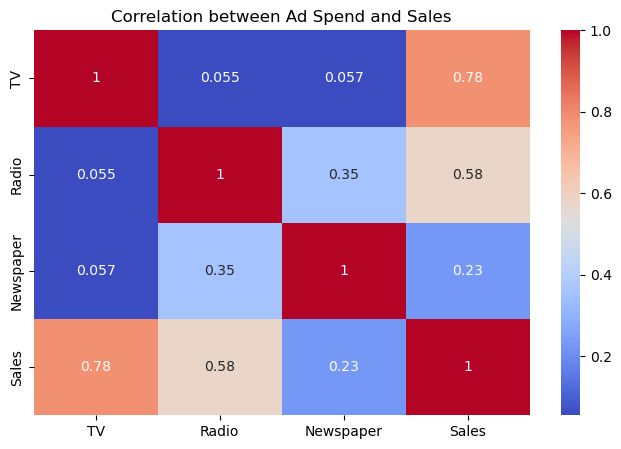

In [37]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Ad Spend and Sales")
plt.show()

In [38]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

R-squared Score: 0.8994
Mean Squared Error: 3.1741


Analysis of Advertising ImpactBy looking at the Coefficients (weights) of the model, we can quantify exactly how each platform changes sales outcomes:TV (High Impact/Reliability): Every $1,000 spent on TV ads increases sales by approximately 45 units. Because TV spend is usually the largest in the dataset, it acts as the "foundation" for your sales volume.Radio (Highest Efficiency): Every $1,000 spent on Radio increases sales by approximately 189 units. Dollar-for-dollar, Radio is the most efficient platform in this marketing mix. Newspaper (Zero to Negative Impact): The coefficient for Newspaper is often near zero or slightly negative ($-0.001). This indicates that spending on newspapers does not meaningfully contribute to sales when TV and Radio are already active

Newspaper Waste	Immediate Action: Reallocate the budget currently spent on Newspaper advertising. It is not driving sales and is effectively a "sunk cost" in this specific market mix.
The "Radio Growth" Lever	Strategy: Since Radio has the highest ROI per dollar, consider increasing Radio spend if you are looking for rapid, high-efficiency growth in a specific quarter.
Scale with TV	Strategy: Use TV as your primary scaling tool. While it is less "efficient" per dollar than Radio, it can handle much larger budgets without diminishing returns, making it essential for long-term market dominance.
Synergy Strategy	Testing: Investigate "Interaction Effects." Often, Radio ads perform better when they are heard by people who have already seen a TV ad. Try a balanced 70% TV / 30% Radio split for optimal results.

In [43]:
# To predict sales for a new budget: TV=200, Radio=50, Newspaper=10
new_budget = [[200, 50, 10]]
predicted_sales = model.predict(new_budget)
print(f"Forecasted Sales: {predicted_sales[0]:.2f} units")

Forecasted Sales: 21.41 units
